In [14]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
from pathlib import Path
import sys

# Navigate from notebook dir (supp_fig_8.../  → supp_figures/ → code/ → project root)
sys.path.insert(0, str(Path.cwd().parents[2]))
from config import ANALYSIS_DATA

fig_width = 7
fig_height = 4.5

sns.set_context('poster')

save_path = str(ANALYSIS_DATA) + '/'

In [15]:
df = pd.read_csv(save_path + 'log_odds_single_trial_errors_normalized.csv', index_col=0)

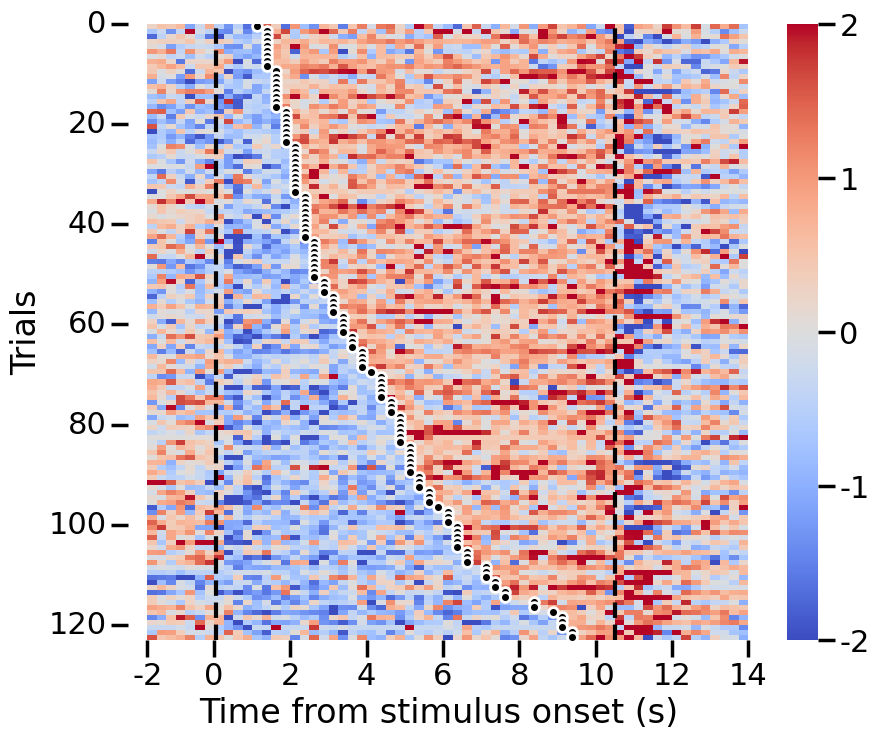

In [16]:
# Pivot the DataFrame to get a matrix format suitable for heatmap
aggregated_df = df.groupby(['trial','trial_change', 'times']).agg({'log_odds': 'mean'}).reset_index()

# Define the interval of times (e.g., 0.125 to 0.375)

time_interval = [0.125, 0.375, 0.625, 0.875, 1.125, 1.375, 1.625, 1.875,
                    2.125, 2.375, 2.625, 2.875, 3.125, 3.375, 3.625, 3.875,
                    4.125, 4.375, 4.625, 4.875, 5.125, 5.375, 5.625, 5.875,
                    6.125, 6.375, 6.625, 6.875, 7.125, 7.375, 7.625, 7.875,
                    8.125, 8.375, 8.625, 8.875, 9.125, 9.375, 9.625, 9.875,
                    10.125]

# restrict to bins of interest
search_df = aggregated_df[aggregated_df['times'].isin(time_interval)]

# define early and late windows
early_window = search_df['times'] < 1.5    # first 2 seconds
# late_window  = search_df['times'] >= time_interval[-4]  # last few bins; change if needed

# compute per-trial early and late means
trial_stats = (
    search_df
    .groupby('trial')
    .apply(lambda x: pd.Series({
        'early_mean': x.loc[early_window.loc[x.index], 'log_odds'].mean(),
        # 'late_mean':  x.loc[late_window.loc[x.index],  'log_odds'].mean()
    }))
)

# keep only trials with early negative and late positive
valid_trials = trial_stats[
    (trial_stats['early_mean'] < 0) 
].index

# # Final filtered dataset
search_df = search_df[search_df['trial'].isin(valid_trials)]
aggregated_df = aggregated_df[aggregated_df['trial'].isin(valid_trials)]

# Function to find the first change point
def find_first_change_point(values, neg_count, pos_count):
    for i in range(len(values) - (neg_count + pos_count - 1)):
        if all(values[i:i+neg_count] < 0.25) and all(values[i+neg_count:i+neg_count+pos_count] > -0.25):
            return i + neg_count
    return None

# Find the first time where there is a chance with the 
change_points = []
for trial in search_df['trial_change'].unique():
    trial_data = search_df[search_df['trial_change'] == trial]
    values = trial_data['log_odds'].values
    point = find_first_change_point(values, 3,3)
    if point is not None:
        change_points.append((trial, trial_data['times'].iloc[point]))

# change_points is a list of (trial_change, change_time)
for trial_change, change_time in change_points:
    mask = (
        (aggregated_df['trial_change'] == trial_change) &
        (aggregated_df['times'] >= change_time) &
        (aggregated_df['times'] <= 10.375)
    )
    
    mask = (
        (aggregated_df['trial_change'] == trial_change) &
        (aggregated_df['times'] <= change_time) &
        (aggregated_df['times'] >= 0)
    )
    
# Sort the trials based on the identified transition points
sorted_trials = sorted(change_points, key=lambda x: x[1])

# Extract the sorted trial_change order
sorted_trial_change = [trial for trial, _ in sorted_trials]

# Pivot the DataFrame to get a matrix format suitable for heatmap
heatmap_data = aggregated_df.pivot(index="trial_change", columns='times', values="log_odds")

# Reorder the heatmap_data based on the sorted trial_change
heatmap_data = heatmap_data.loc[sorted_trial_change]

# Plot the heatmap
plt.figure(figsize=(10, 8))
ax = sns.heatmap(heatmap_data, center=0, vmin=-2, vmax=2, cmap='coolwarm', rasterized=True )

# Highlight the change points
for trial, time in change_points:
    plt.scatter(heatmap_data.columns.get_loc(time) + 0.5, heatmap_data.index.get_loc(trial) + 0.5, color='black', s=50, edgecolors='white')

# Plot a vertical line at time 0
ax.axvline(x=heatmap_data.columns.get_loc(0.125) - 0.75, color='black', linestyle='--')
ax.axvline(x=heatmap_data.columns.get_loc(10.375), color='black', linestyle='--')

# Set y ticks: every 5 trials
y_ticks = np.arange(0, heatmap_data.shape[0], 20)
plt.yticks(ticks=y_ticks, labels=[f"{y}" for y in y_ticks])
plt.xlim(-2,18)
plt.ylabel("Trials")
# Choose nice tick labels
nice_times = [-2, 0, 2, 4, 6, 8, 10, 12, 14]

# Find nearest indices in heatmap columns
x_positions = [np.argmin(np.abs(heatmap_data.columns - t)) for t in nice_times]

cbar = ax.collections[0].colorbar
cbar.set_ticks([-2, -1, 0, 1, 2])
cbar.set_ticklabels(['-2', '-1', '0', '1', '2'])

# Set x-axis for heatmap
ax.set_xticks(x_positions)
ax.set_xticklabels([f"{t:}" for t in nice_times], rotation=360)
ax.set_xlabel("Time from stimulus onset (s)")
# plt.savefig(rf"G:\My Drive\WORKING_MEMORY\PAPER\2ND_SUBMISSION_NAT_NEURO\figures_for_resubmission\Fig. 1.6. Reversals\reversal_trials_heatmap_aligned_stimulus_v2.svg", dpi = 1000)
plt.show()

(-1.0, 1.0)

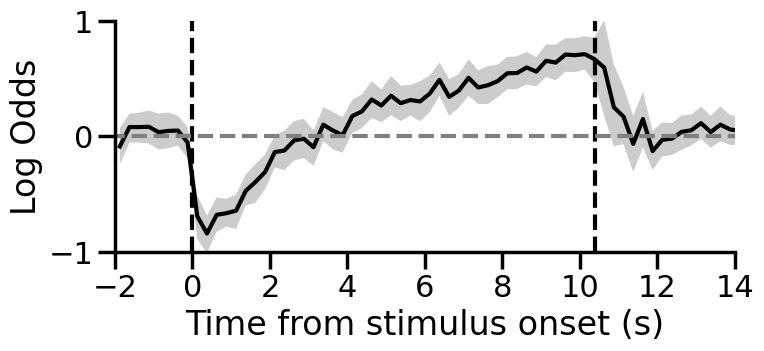

In [17]:
fig = plt.figure(figsize=(8, 3))
# sns.lineplot(x='times',y='log_odds',data= filtered_df.loc[filtered_df['trial'].isin(valid_trials)], color='black', errorbar='ci',err_style='band', err_kws={"edgecolor": "none"})
sns.lineplot(x='times',y='log_odds',data= aggregated_df, color='black', errorbar='ci',err_style='band', err_kws={"edgecolor": "none"})

sns.despine()
plt.axvline(x=0, color='black', linestyle='--')
plt.axvline(x=10.4, color='black', linestyle='--')
plt.axhline(0, -2, 14, linestyle='--', color='grey')
plt.xlim(-2,14)
plt.ylabel("Log Odds")
plt.xlabel("Time from stimulus onset (s)")
plt.xticks(np.arange(-2,15,2))
plt.ylim(-1, 1)
# plt.savefig(rf"G:\My Drive\WORKING_MEMORY\PAPER\2ND_SUBMISSION_NAT_NEURO\figures_for_resubmission\Fig. 1.6. Reversals\filtered_log_odds_aligned_stimulus_v2.svg", dpi=300, bbox_inches='tight')

In [18]:
df_change_points = pd.DataFrame(change_points, columns=['trial_change', 'time'])
# new_df = aggregated_df.loc[aggregated_df.trial.isin(valid_trials)].merge(df_change_points, on='trial_change', how='left')
new_df = aggregated_df.merge(df_change_points, on='trial_change', how='left')

new_df['time_reversal_aligned'] = new_df['times'] - new_df['time']

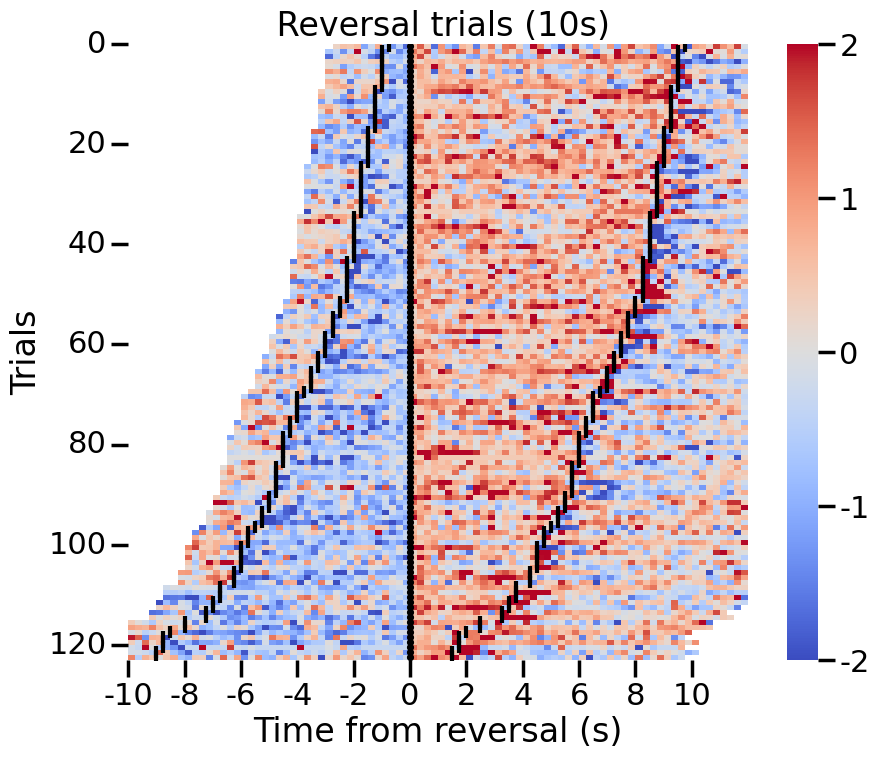

In [19]:

# Pivot the DataFrame to get a matrix format suitable for heatmap
# plot_df = new_df.loc[new_df.times.isin([0.125, 0.375, 0.625, 0.875, 1.125, 1.375, 1.625, 1.875,
#                      2.125, 2.375, 2.625, 2.875, 3.125, 3.375, 3.625, 3.875,
#                      4.125, 4.375, 4.625, 4.875, 5.125, 5.375, 5.625, 5.875,
#                      6.125, 6.375, 6.625, 6.875, 7.125, 7.375, 7.625, 7.875,
#                      8.125, 8.375, 8.625, 8.875, 9.125, 9.375, 9.625, 9.875,
#                      10.125])]
plot_df = new_df.copy()

simple_df = plot_df[['trial_change', 'time_reversal_aligned', 'log_odds']].dropna()
heatmap_data = simple_df.pivot(index="trial_change", columns='time_reversal_aligned', values="log_odds")

# Reorder the heatmap_data based on the sorted trial_change
heatmap_data = heatmap_data.loc[sorted_trial_change]

# Plot the heatmap
plt.figure(figsize=(10, 8))
ax = sns.heatmap(heatmap_data, center=0, vmin=-2, vmax=2, cmap='coolwarm', rasterized=True)


# Set y ticks: every 5 trials
y_ticks = np.arange(0, heatmap_data.shape[0], 20)
plt.yticks(ticks=y_ticks, labels=[f"{y}" for y in y_ticks])

plt.ylabel("Trials")
# Choose nice tick labels
nice_times = [-10, -8, -6, -4, -2, 0, 2, 4, 6, 8,10]

# Find nearest indices in heatmap columns
x_positions = [np.argmin(np.abs(heatmap_data.columns - t)) for t in nice_times]

for i, trial in enumerate(heatmap_data.index):
    test = plot_df[plot_df.trial_change == trial]
    line_val = test.loc[test.times == 0.125, 'time_reversal_aligned'].iloc[0]
    x_pos = heatmap_data.columns.get_loc(line_val)  # convert to column index
    ax.scatter(x_pos, i+0.5, color='black', s=70, marker='|')
    
    line_val = test.loc[test.times ==  10.625, 'time_reversal_aligned'].iloc[0]
    x_pos = heatmap_data.columns.get_loc(line_val)  # convert to column index
    ax.scatter(x_pos, i+0.5, color='black', s=70, marker='|')

# Set x-axis for heatmap
ax.set_xticks(x_positions)
ax.set_xticklabels([f"{t:}" for t in nice_times], rotation=360)
ax.set_xlim(4,92)
for t in [0]:
    x_pos = np.argmin(np.abs(heatmap_data.columns - t))
    # Plot a dot at each row for this vertical line
    y_positions = np.arange(heatmap_data.shape[0])
    x_positions = np.full_like(y_positions, x_pos)
    ax.scatter(x_positions, y_positions + 0.5, color='black', s=10)  # +0.5 to center in cell

cbar = ax.collections[0].colorbar
cbar.set_ticks([-2, -1, 0, 1, 2])
cbar.set_ticklabels(['-2', '-1', '0', '1', '2'])
plt.title(" Reversal trials (10s)")
plt.xlabel("Time from reversal (s)")
# plt.savefig(rf"G:\My Drive\WORKING_MEMORY\PAPER\2ND_SUBMISSION_NAT_NEURO\figures_for_resubmission\Fig. 1.6. Reversals\reversal_trials_heatmap_aligned_reversal_v2.svg", dpi = 300)
plt.show()

(-1.25, 1.25)

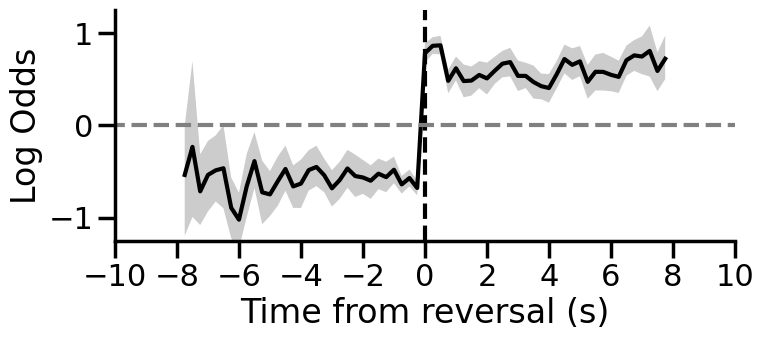

In [20]:
fig = plt.figure(figsize=(8, 3))
plot_df = new_df.loc[new_df.times.isin([0.125, 0.375, 0.625, 0.875, 1.125, 1.375, 1.625, 1.875,
                     2.125, 2.375, 2.625, 2.875, 3.125, 3.375, 3.625, 3.875,
                     4.125, 4.375, 4.625, 4.875, 5.125, 5.375, 5.625, 5.875,
                     6.125, 6.375, 6.625, 6.875, 7.125, 7.375, 7.625, 7.875,
                     8.125, 8.375, 8.625, 8.875, 9.125, 9.375, 9.625, 9.875,
                     10.125])]
simple_df = plot_df[['trial_change', 'time_reversal_aligned', 'log_odds']].dropna()
simple_df = simple_df.loc[(simple_df.time_reversal_aligned < 8) & (simple_df.time_reversal_aligned > -8)]
heatmap_data = simple_df.pivot(index="trial_change", columns='time_reversal_aligned', values="log_odds")

sns.lineplot(x='time_reversal_aligned',y='log_odds',data= simple_df, color='black', errorbar='ci',err_kws={"edgecolor": "none"})
sns.despine()
plt.axvline(x=0, color='black', linestyle='--')
plt.axhline(0, -6, 614, linestyle='--', color='grey')

plt.ylabel("Log Odds")
plt.xlabel("Time from reversal (s)")
plt.xticks(np.arange(-10,12,2))
plt.xlim(-10,10)
plt.ylim(-1.25, 1.25)
# plt.savefig(rf"G:\My Drive\WORKING_MEMORY\PAPER\2ND_SUBMISSION_NAT_NEURO\figures_for_resubmission\Fig. 1.6. Reversals\filtered_log_odds_aligned_reversal_v2.svg", dpi=300, bbox_inches='tight')

## Same as above but using shuffle data

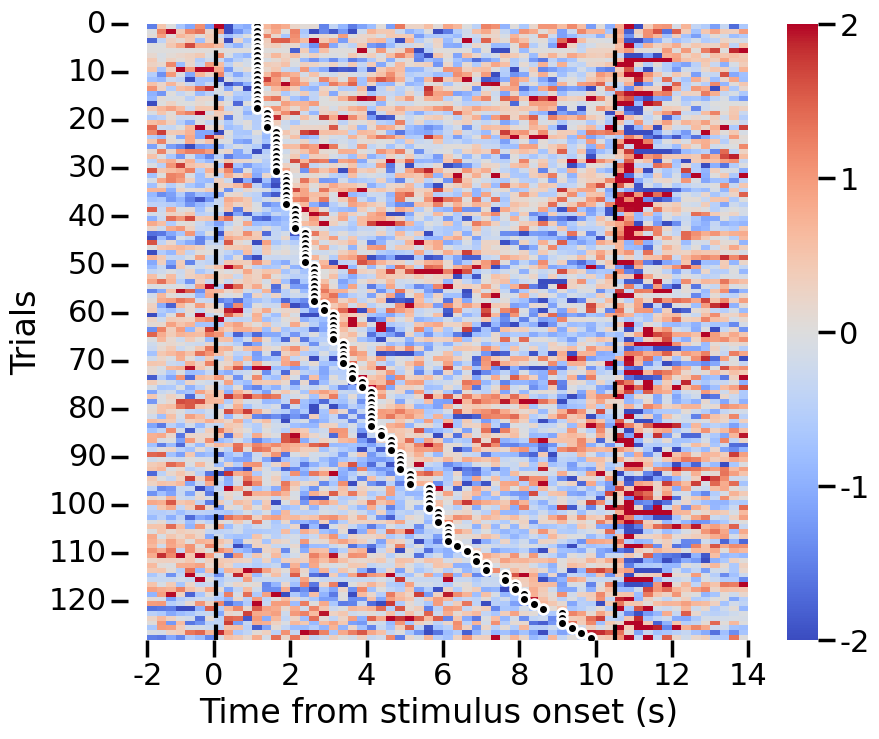

In [10]:
# -----------------------------
# Parameters
# -----------------------------
chunk_size = 3
shuffle_bins = [0.125, 0.375, 0.625, 0.875, 1.125, 1.375, 1.625, 1.875,
                2.125, 2.375, 2.625, 2.875, 3.125, 3.375, 3.625, 3.875,
                4.125, 4.375, 4.625, 4.875, 5.125, 5.375, 5.625, 5.875,
                6.125, 6.375, 6.625, 6.875, 7.125, 7.375, 7.625, 7.875,
                8.125, 8.375, 8.625, 8.875, 9.125, 9.375, 9.625, 9.875,
                10.125]

all_times = np.sort(aggregated_df['times'].unique())
trials = search_df['trial_change'].unique()

# -----------------------------
# Helper functions
# -----------------------------
def chunk_list(lst, n):
    return [lst[i:i+n] for i in range(0, len(lst), n)]

def flatten(lst_of_lsts):
    return [x for sub in lst_of_lsts for x in sub]

def find_first_change_point(values, neg_count=3, pos_count=3):
    for i in range(len(values) - (neg_count + pos_count - 1)):
        if all(values[i:i+neg_count] < 0.25) and all(values[i+neg_count:i+neg_count+pos_count] > -0.25):
            return i + neg_count
    return None

# -----------------------------
# Shuffle log_odds in shuffle_bins only
# -----------------------------
shuffled_trials = []
rng = np.random.default_rng()

for trial_id, trial_data in search_df.groupby('trial_change'):
    trial_data = trial_data.copy()
    mask = trial_data['times'].isin(shuffle_bins)
    
    # chunk and shuffle
    chunks = chunk_list(list(trial_data.loc[mask, 'log_odds']), chunk_size)
    for c in chunks:
        rng.shuffle(c)
    perm = rng.permutation(len(chunks))
    chunks_shuffled = [chunks[i] for i in perm]
    trial_data.loc[mask, 'log_odds'] = flatten(chunks_shuffled)
    shuffled_trials.append(trial_data)

shuffled_df = pd.concat(shuffled_trials)

# -----------------------------
# Full grid to ensure all trial × time combinations exist
# -----------------------------
# full_grid = pd.MultiIndex.from_product([trials, all_times], names=['trial_change','times'])
# full_df = pd.DataFrame(index=full_grid).reset_index()

# # Merge the **original log_odds** from search_df
# full_df = full_df.merge(
#     aggregated_df[['trial_change','times','log_odds']],
#     on=['trial_change','times'],
#     how='left'
# )

# # Merge the **shuffled log_odds** from shuffled_df
# full_df = full_df.merge(
#     shuffled_df[['trial_change','times','log_odds']],
#     on=['trial_change','times'],
#     how='left',
#     suffixes=('_original','_shuffled')
# )

full_df = aggregated_df.loc[aggregated_df.trial_change.isin(trials)].merge( shuffled_df[['trial_change','times','log_odds']], on=['trial_change','times'], how='left', suffixes=('_original','_shuffled') )

# Use shuffled value if exists, else original
full_df['log_odds_final'] = full_df['log_odds_shuffled'].combine_first(full_df['log_odds_original'])

# -----------------------------
# Pivot for heatmap
# -----------------------------
heatmap_data = full_df.pivot(index='trial_change', columns='times', values='log_odds_final')

# -----------------------------
# Detect change points only in shuffle bins
# -----------------------------
change_points = []

# Find the positions of the shuffled bins
shuffle_col_idx = [i for i, t in enumerate(heatmap_data.columns) if t in shuffle_bins]
shuffle_cols = [heatmap_data.columns[i] for i in shuffle_col_idx]

for trial_pos, trial_label in enumerate(heatmap_data.index):
    # Extract only the values corresponding to shuffled bins
    values_shuffle = heatmap_data.loc[trial_label, shuffle_cols].values
    idx_in_shuffle = find_first_change_point(values_shuffle)
    
    if idx_in_shuffle is not None:
        # Map index back to the original column in heatmap_data
        original_col = shuffle_cols[idx_in_shuffle]
        change_points.append((trial_label, original_col))

# Sort trials by change point
sorted_trials = sorted(change_points, key=lambda x: x[1])

# Extract the sorted trial_change order
sorted_trial_change = [trial for trial, _ in sorted_trials]
heatmap_data = heatmap_data.loc[[t for t,_ in sorted_trials]]


# -----------------------------
# Plot heatmap
# -----------------------------
plt.figure(figsize=(10,8))
ax = sns.heatmap(heatmap_data, center=0, vmin=-2, vmax=2, cmap='coolwarm', rasterized=True)

# Highlight change points
for trial, time in change_points:
    plt.scatter(
        heatmap_data.columns.get_loc(time)+0.5,
        heatmap_data.index.get_loc(trial)+0.5,
        color='black', s=50, edgecolors='white'
    )

# X-axis
ax.set_xticks(np.arange(len(all_times)))
ax.set_xticklabels([f"{t:.3g}" for t in all_times], rotation=360)
ax.set_xlabel("Time from stimulus onset (s)")

# Y-axis
y_ticks = np.arange(0, heatmap_data.shape[0], 20)
plt.yticks(ticks=y_ticks, labels=[f"{y}" for y in y_ticks])
plt.ylabel("Trials")
# Plot a vertical line at time 0
ax.axvline(x=heatmap_data.columns.get_loc(0.125) - 0.75, color='black', linestyle='--')
ax.axvline(x=heatmap_data.columns.get_loc(10.375), color='black', linestyle='--')

# Set y ticks: every 5 trials
y_ticks = np.arange(0, heatmap_data.shape[0], 10)
plt.yticks(ticks=y_ticks, labels=[f"{y}" for y in y_ticks])
plt.xlim(-2,18)
plt.ylabel("Trials")
# Choose nice tick labels
nice_times = [-2, 0, 2, 4, 6, 8, 10, 12, 14]

# Find nearest indices in heatmap columns
x_positions = [np.argmin(np.abs(heatmap_data.columns - t)) for t in nice_times]

# Set x-axis for heatmap
ax.set_xticks(x_positions)
ax.set_xticklabels([f"{t:}" for t in nice_times], rotation=360)
ax.set_xlabel("Time from stimulus onset (s)")
cbar = ax.collections[0].colorbar
cbar.set_ticks([-2, -1, 0, 1, 2])
cbar.set_ticklabels(['-2', '-1', '0', '1', '2'])

# plt.savefig(rf"G:\My Drive\WORKING_MEMORY\PAPER\2ND_SUBMISSION_NAT_NEURO\figures_for_resubmission\Fig. 1.6. Reversals\reversal_trials_heatmap_aligned_stimulus_shuffled_v2.svg", dpi = 1000)
plt.show()


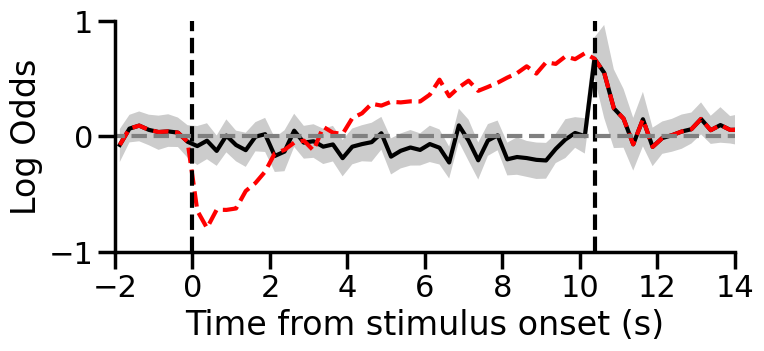

In [11]:
fig = plt.figure(figsize=(8, 3))

# Use full_df to include both shuffled and protected bins
sns.lineplot(
    x='times',
    y='log_odds_final',
    data=full_df,  # contains shuffled + protected bins
    color='black',
    errorbar='ci',
    err_style='band',
    err_kws={"edgecolor": "none"}
)

sns.lineplot(
    x='times',
    y='log_odds',
    data=aggregated_df,  # original for comparison
    color='red',
    linestyle='--',
    errorbar=None
)
sns.despine()

# Vertical reference lines
plt.axvline(x=0, color='black', linestyle='--')
plt.axvline(x=10.4, color='black', linestyle='--')

# Horizontal reference line
plt.axhline(0, -2, 14, linestyle='--', color='grey')

# Axes limits and labels
plt.xlim(-2, 14)
plt.ylim(-1, 1)
plt.ylabel("Log Odds")
plt.xlabel("Time from stimulus onset (s)")

# X-axis ticks
plt.xticks(np.arange(-2, 15, 2))

# Optional: save figure
plt.savefig(r"G:\My Drive\WORKING_MEMORY\PAPER\2ND_SUBMISSION_NAT_NEURO\figures_for_resubmission\Fig. 1.6. Reversals\log_odds_aligned_reversal_shuffle.svg", dpi=300, bbox_inches='tight')
plt.show()


In [12]:
df_change_points = pd.DataFrame(change_points, columns=['trial_change', 'time'])
# new_df = aggregated_df.loc[aggregated_df.trial.isin(valid_trials)].merge(df_change_points, on='trial_change', how='left')
new_df = full_df.merge(df_change_points, on='trial_change', how='left')

new_df['time_reversal_aligned'] = new_df['times'] - new_df['time']
new_df.rename(columns={'log_odds_final':'log_odds'}, inplace=True)

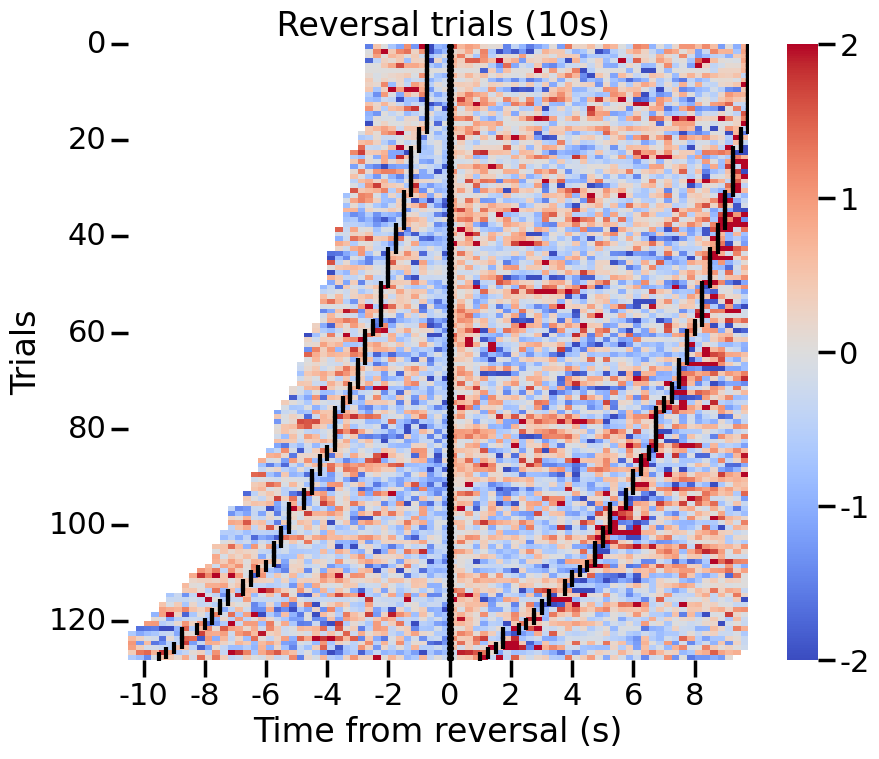

In [ ]:

plot_df = new_df.copy()

simple_df = plot_df[['trial_change', 'time_reversal_aligned', 'log_odds']].dropna()
heatmap_data = simple_df.pivot(index="trial_change", columns='time_reversal_aligned', values="log_odds")

# Reorder the heatmap_data based on the sorted trial_change
heatmap_data = heatmap_data.loc[sorted_trial_change]

# Plot the heatmap
plt.figure(figsize=(10, 8))
ax = sns.heatmap(heatmap_data, center=0, vmin=-2, vmax=2, cmap='coolwarm', rasterized=True)


# Set y ticks: every 5 trials
y_ticks = np.arange(0, heatmap_data.shape[0], 20)
plt.yticks(ticks=y_ticks, labels=[f"{y}" for y in y_ticks])

plt.ylabel("Trials")
# Choose nice tick labels
nice_times = [-10, -8, -6, -4, -2, 0, 2, 4, 6, 8,10]

# Find nearest indices in heatmap columns
x_positions = [np.argmin(np.abs(heatmap_data.columns - t)) for t in nice_times]

for i, trial in enumerate(heatmap_data.index):
    test = plot_df[plot_df.trial_change == trial]
    line_val = test.loc[test.times == 0.125, 'time_reversal_aligned'].iloc[0]
    x_pos = heatmap_data.columns.get_loc(line_val)  # convert to column index
    ax.scatter(x_pos, i+0.5, color='black', s=70, marker='|')
    
    line_val = test.loc[test.times ==  10.625, 'time_reversal_aligned'].iloc[0]
    x_pos = heatmap_data.columns.get_loc(line_val)  # convert to column index
    ax.scatter(x_pos, i+0.5, color='black', s=70, marker='|')

# Set x-axis for heatmap
ax.set_xticks(x_positions)
ax.set_xticklabels([f"{t:}" for t in nice_times], rotation=360)
ax.set_xlim(4,85)
for t in [0]:
    x_pos = np.argmin(np.abs(heatmap_data.columns - t))
    # Plot a dot at each row for this vertical line
    y_positions = np.arange(heatmap_data.shape[0])
    x_positions = np.full_like(y_positions, x_pos)
    ax.scatter(x_positions, y_positions + 0.5, color='black', s=10)  # +0.5 to center in cell

cbar = ax.collections[0].colorbar
cbar.set_ticks([-2, -1, 0, 1, 2])
cbar.set_ticklabels(['-2', '-1', '0', '1', '2'])
plt.title(" Reversal trials (10s)")
plt.xlabel("Time from reversal (s)")
# plt.savefig(rf"G:\My Drive\WORKING_MEMORY\PAPER\2ND_SUBMISSION_NAT_NEURO\figures_for_resubmission\Fig. 1.6. Reversals\reversal_trials_heatmap_aligned_reversal_shuffle.svg", dpi = 300)
plt.show()

(-1.25, 1.25)

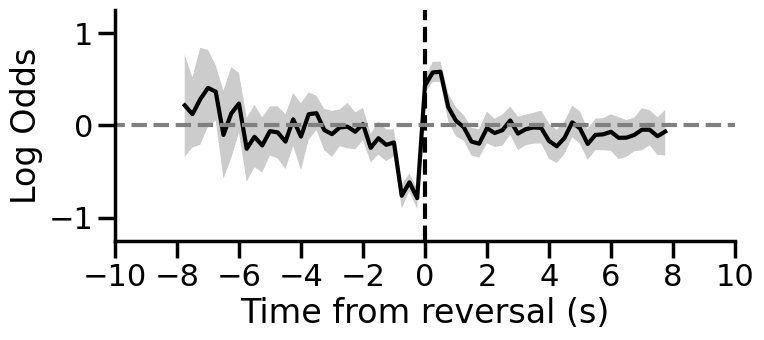

In [14]:
fig = plt.figure(figsize=(8, 3))
plot_df = new_df.loc[new_df.times.isin([0.125, 0.375, 0.625, 0.875, 1.125, 1.375, 1.625, 1.875,
                     2.125, 2.375, 2.625, 2.875, 3.125, 3.375, 3.625, 3.875,
                     4.125, 4.375, 4.625, 4.875, 5.125, 5.375, 5.625, 5.875,
                     6.125, 6.375, 6.625, 6.875, 7.125, 7.375, 7.625, 7.875,
                     8.125, 8.375, 8.625, 8.875, 9.125, 9.375, 9.625, 9.875,
                     10.125])]
simple_df = plot_df[['trial_change', 'time_reversal_aligned', 'log_odds']].dropna()
simple_df = simple_df.loc[(simple_df.time_reversal_aligned < 8) & (simple_df.time_reversal_aligned > -8)]
heatmap_data = simple_df.pivot(index="trial_change", columns='time_reversal_aligned', values="log_odds")

sns.lineplot(x='time_reversal_aligned',y='log_odds',data= simple_df, color='black', errorbar='ci',err_kws={"edgecolor": "none"})
sns.despine()
plt.axvline(x=0, color='black', linestyle='--')
plt.axhline(0, -6, 614, linestyle='--', color='grey')

plt.ylabel("Log Odds")
plt.xlabel("Time from reversal (s)")
plt.xticks(np.arange(-10,12,2))
plt.xlim(-10,10)
plt.ylim(-1.25, 1.25)
# plt.savefig(rf"G:\My Drive\WORKING_MEMORY\PAPER\2ND_SUBMISSION_NAT_NEURO\figures_for_resubmission\Fig. 1.6. Reversals\filtered_log_odds_aligned_reversal_shufle.svg", dpi=300, bbox_inches='tight')